In [1]:
import os
import matplotlib.pyplot as plt
import shutil
import numpy as np

import sys
from pathlib import Path
import os

In [2]:
# Me aseguro de que el directorio raíz del proyecto esté en el sys.path
project_root = Path(os.path.abspath("")).parent

# Añado el directorio raíz al sys.path si no está ya presente
if project_root not in sys.path:
    sys.path.append(str(project_root))

In [3]:
from src.config import raw_data_dir, interim_data_dir, load_config

from src.utils.images import convertir_jpg_a_png_2, copiar_png_existente_2


Current working directory: /home/jorge/development/WasteImageReconstructionDL/notebooks
Loading configuration from /home/jorge/development/WasteImageReconstructionDL/src/config.yaml


In [4]:
# Cargo la configuración 
config = load_config()

Loading configuration from /home/jorge/development/WasteImageReconstructionDL/src/config.yaml


In [5]:
# Directorio del dataset original
dataset_dir = interim_data_dir() / 'dataset'


### Calcular y graficar cuántas imágenes son PNG y JPG

In [6]:
# Contadores para las extensiones de archivos
jpg_count = 0
png_count = 0

In [7]:
# Contamos la cantidad de archivos JPG y PNG en cada subdirectorio
for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.endswith('.jpg') or file.endswith('.jpeg'):  # Incluye también archivos .jpeg
            jpg_count += 1
        elif file.endswith('.png'):
            png_count += 1

In [8]:
# Datos para la gráfica
labels = ['JPG', 'PNG']
counts = [jpg_count, png_count]

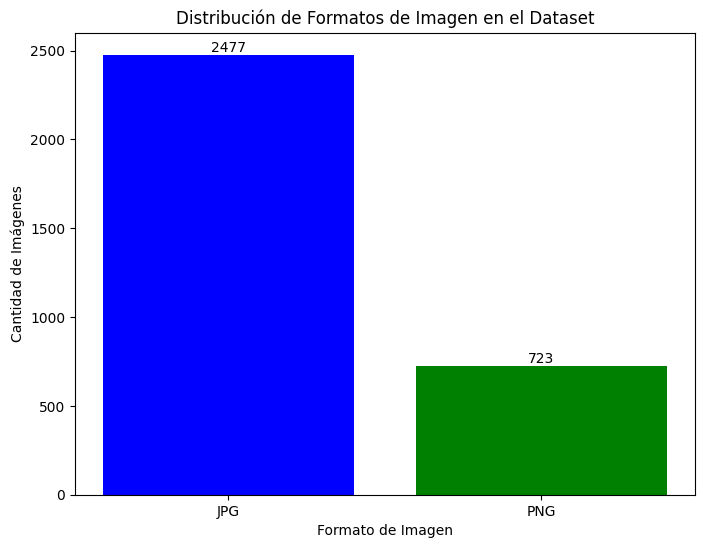

In [9]:
# Creamos la gráfica
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, counts, color=['blue', 'green'])

# Agregamos los números encima de las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom')

plt.xlabel('Formato de Imagen')
plt.ylabel('Cantidad de Imágenes')
plt.title('Distribución de Formatos de Imagen en el Dataset')
plt.show()

### Convertir las imágenes JPG a PNG

In [10]:
#input_dir = 'data/interim/dataset'
input_dir = interim_data_dir() / 'dataset'
output_dir = interim_data_dir() / 'dataset_png'
max_workers = 18 # Número de procesos a lanzar para covertir y copiar archivos

In [11]:
convertir_jpg_a_png_2(input_dir, output_dir, max_workers)


### Copiar las imágenes PNG existentes al nuevo directorio

In [12]:
copiar_png_existente_2(input_dir, output_dir, max_workers)